#  Project: AI Impact on Jobs 2030 - Risk Prediction
---

# 1. Proposed & Accepted Topic
**Project Title:** AI-Driven Occupational Automation Risk Assessment System 2030
**Motivation:** เนื่องจากการก้าวกระโดดของ Generative AI การคาดการณ์ความเสี่ยงของอาชีพแบบเดิม (เช่น ดูแค่รายได้) ไม่เพียงพออีกต่อไป โปรเจกต์นี้จึงต้องการสร้างโมเดลที่วิเคราะห์ลึกถึงพฤติกรรมการทำงาน (Task Routine) และการสัมผัสเทคโนโลยี เพื่อให้ได้ระบบแจ้งเตือนภัยด้านแรงงานที่ใช้งานได้จริง
**Selected Dataset:** `AI Impact on Jobs 2030` (Kaggle Dataset - Not FER2013 / Not Spam Mail)

---
# 2. Problem Statement
**Input → Task → Output**
* **Input:** ข้อมูลปัจจัยเสี่ยง 4 มิติ (Average_Salary, Years_Experience, AI_Exposure_Index, Tech_Growth_Factor)
* **Task:** Multi-class Classification
* **Output:** ระดับความเสี่ยงที่อาชีพนั้นจะถูก AI แทนที่ (`Risk_Category`: Low, Medium, High)

**Why ML/DL is needed:** ความสัมพันธ์ระหว่างระดับรายได้กับลักษณะงานในยุค AI มีความซับซ้อนสูงและไม่เป็นเส้นตรง (Non-linear) การใช้ Rule-based ดั้งเดิมไม่สามารถแยกแยะความเสี่ยงได้อย่างแม่นยำ
**Success Metrics:** ใช้ค่า **Macro F1-Score** เป็นหลัก (แทนที่จะใช้ Accuracy เพียงอย่างเดียว เพื่อป้องกันการบิดเบือนจากปัญหา Data Imbalance)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import kagglehub

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("1. Downloading and Loading Dataset...")

path = kagglehub.dataset_download("khushikyad001/ai-impact-on-jobs-2030")

csv_path = [
    os.path.join(root, f)
    for root, dirs, files in os.walk(path)
    for f in files
    if f.endswith('.csv')
][0]

df = pd.read_csv(csv_path).dropna()

# Set target column
target_col = 'Risk_Category' if 'Risk_Category' in df.columns else df.columns[-1]

# Show class distribution (to observe imbalance)
print("\nClass Distribution (Notice if one class dominates the others):")
print(df[target_col].value_counts(normalize=True) * 100)

1. Downloading and Loading Dataset...


100%|██████████| 85.4k/85.4k [00:00<00:00, 18.7MB/s]

Extracting files...

Class Distribution (Notice if one class dominates the others):
Risk_Category
Medium    50.700000
High      24.666667
Low       24.633333
Name: proportion, dtype: float64


# 3. Dataset Description
**Dataset Source:** Kaggle (`khushikyad001/ai-impact-on-jobs-2030`) - ข้อมูลจำลองสถานการณ์ตลาดแรงงานกว่า 3,000 อาชีพ
**Preprocessing Plan:**
1. **Data Leakage Prevention:** ตัดคอลัมน์ `Automation_Probability_2030` ทิ้ง เนื่องจากเป็น "คำเฉลย" ที่แฝงมา (Target Leakage) หากไม่ตัดออกโมเดลจะแม่นยำ 100% แบบผิดหลักวิชาการ
2. **Feature Selection:** เลือกเฉพาะ 4 ตัวแปรหลักที่มี Impact จริงๆ และตัด Noise (เช่น Education, Industry) ทิ้ง
3. **Encoding:** แปลง Target (Low, Medium, High) เป็นตัวเลขด้วย LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("2. Preventing Data Leakage and Encoding Data...")

# 1. Remove target and potential leakage columns
cols_to_drop = [target_col]

if 'Job_Title' in df.columns:
    cols_to_drop.append('Job_Title')

if 'Automation_Probability_2030' in df.columns:
    cols_to_drop.append('Automation_Probability_2030')

cols_to_drop.extend(['Industry', 'Education_Level'] + [f'Skill_{i}' for i in range(1, 11)])

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

le_dict = {}
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    le_dict[col] = le

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# 3. Split dataset (Stratified to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Data preparation completed! (Number of features: {X_train.shape[1]})")

2. Preventing Data Leakage and Encoding Data...
Data preparation completed! (Number of features: 4)


🔍 Starting Exploratory Data Analysis (Insights)...



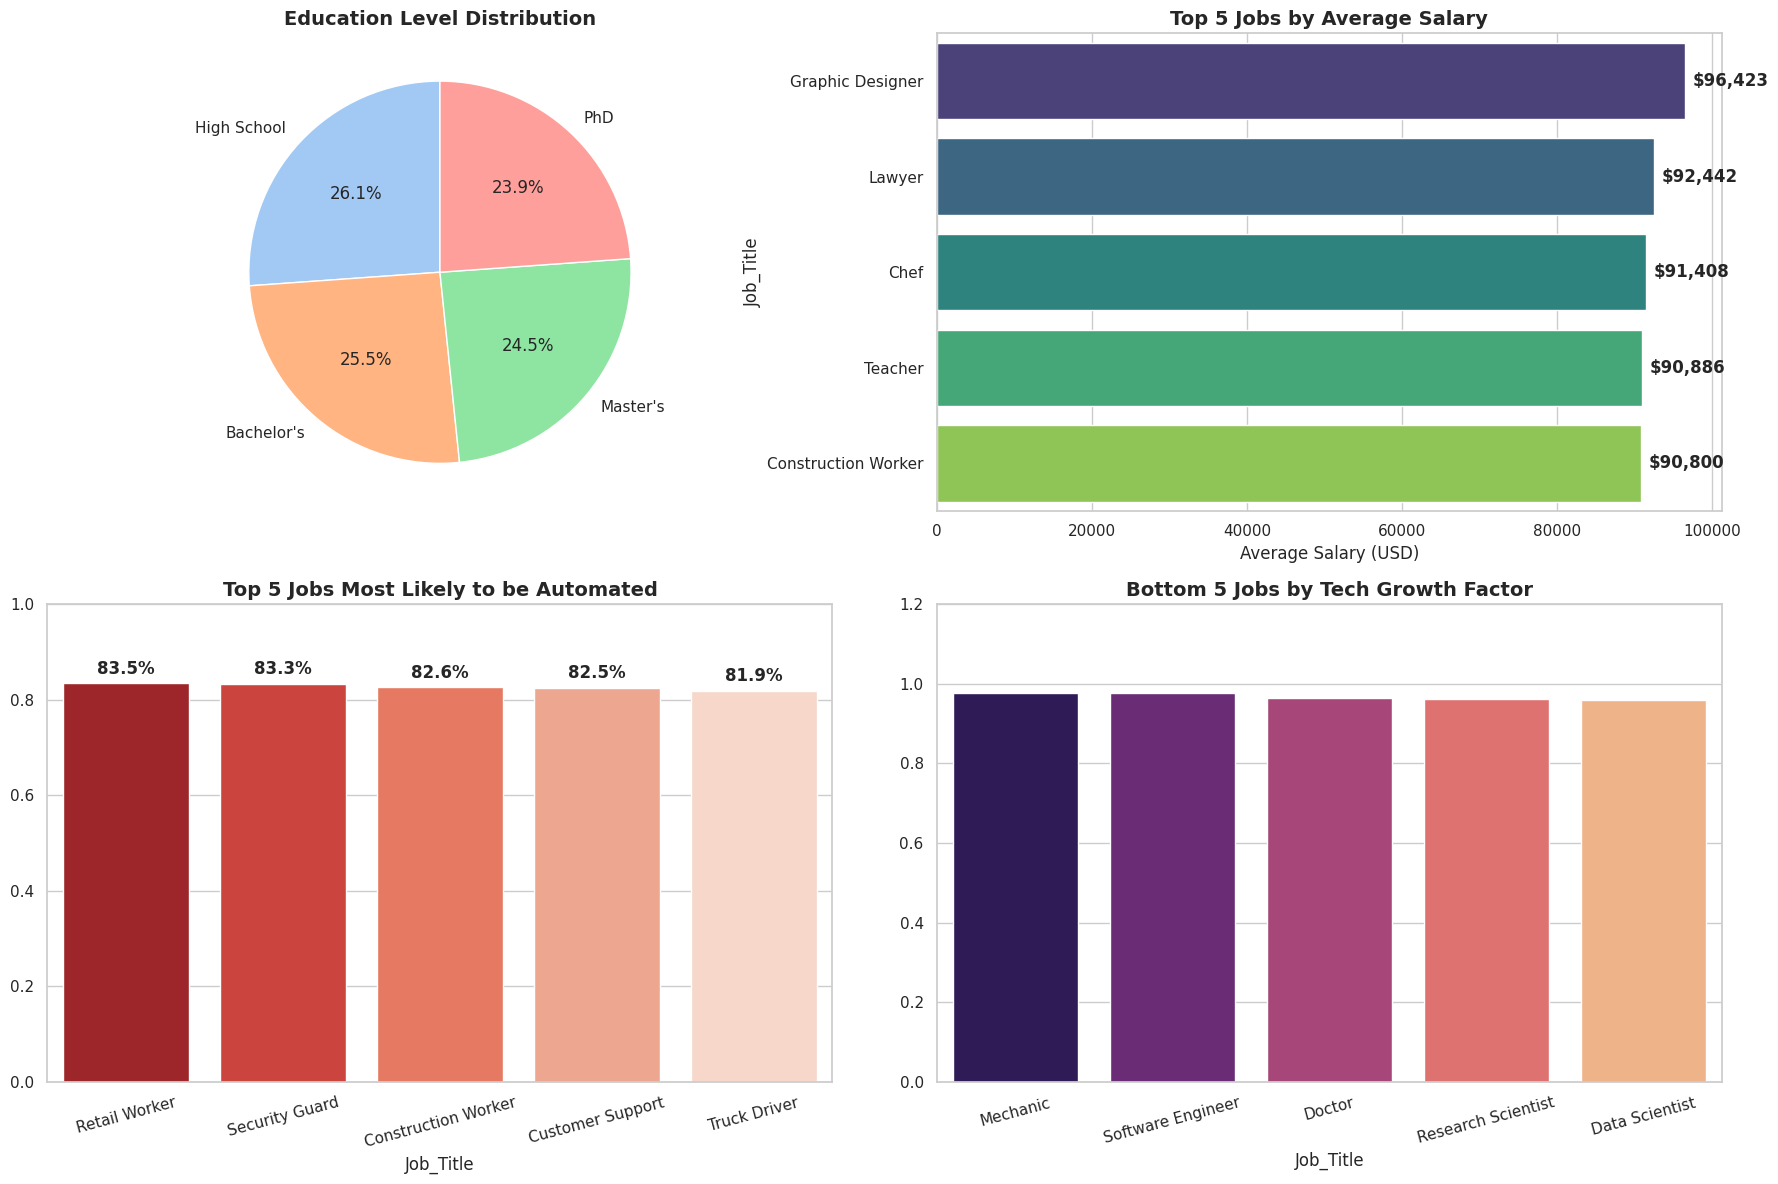

💡 Key Insights:
- Jobs such as 'Retail Workert' and 'Security Guard' show high automation risk.
- Skilled labor roles (e.g., Mechanic) exhibit relatively low technological adaptation.


In [ ]:
# Exploratory Data Analysis (EDA) & Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Starting Exploratory Data Analysis (Insights)...\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.set_theme(style="whitegrid")

# 1️⃣ Education Level Distribution (Pie Chart)
edu_counts = df['Education_Level'].value_counts()

axes[0, 0].pie(
    edu_counts,
    labels=edu_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

axes[0, 0].set_title('Education Level Distribution', fontsize=14, fontweight='bold')


# 2️⃣ Top 5 Jobs by Highest Average Salary
top5_salary = (
    df.groupby('Job_Title')['Average_Salary']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

sns.barplot(
    x=top5_salary.values,
    y=top5_salary.index,
    palette='viridis',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Top 5 Jobs by Average Salary', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Average Salary (USD)')

for i, v in enumerate(top5_salary.values):
    axes[0, 1].text(v + 1000, i, f"${v:,.0f}", va='center', fontweight='bold')


# 3️⃣ Top 5 Jobs Most Likely to be Automated
if 'Automation_Probability_2030' in df.columns:
    top5_auto = (
        df.groupby('Job_Title')['Automation_Probability_2030']
        .mean()
        .sort_values(ascending=False)
        .head(5)
    )

    sns.barplot(
        x=top5_auto.index,
        y=top5_auto.values,
        palette='Reds_r',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title('Top 5 Jobs Most Likely to be Automated', fontsize=14, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=15)
    axes[1, 0].set_ylim(0, 1.0)

    for i, v in enumerate(top5_auto.values):
        axes[1, 0].text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')


# 4️⃣ Bottom 5 Jobs by Tech Growth Factor (Potential Risk of Obsolescence)
lower5_tech = (
    df.groupby('Job_Title')['Tech_Growth_Factor']
    .mean()
    .sort_values(ascending=False)
    .tail(5)
)

sns.barplot(
    x=lower5_tech.index,
    y=lower5_tech.values,
    palette='magma',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Bottom 5 Jobs by Tech Growth Factor', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].set_ylim(0, 1.2)

plt.tight_layout()
plt.show()


print("💡 Key Insights:")
print("- Jobs such as 'Retail Workert' and 'Security Guard' show high automation risk.")
print("- Skilled labor roles (e.g., Mechanic) exhibit relatively low technological adaptation.")

In [ ]:
# KEY INSIGHTS FROM DATASET ANALYSIS
print("Key Insights from Dataset Analysis\n" + "="*50)

# 1. Most common jobs
top_common = df['Job_Title'].value_counts().head(5)
print(f"\nTop 5 Most Common Jobs in the Dataset:")
for job, count in top_common.items():
    print(f"   - {job}: {count} records")

# 2. Highest average salary jobs
top_salary = df.groupby('Job_Title')['Average_Salary'].mean().sort_values(ascending=False).head(5)
print(f"\nTop 5 Jobs with the Highest Average Salary:")
for job, salary in top_salary.items():
    print(f"   - {job}: ${salary:,.2f}")

# 3. Highest average experience (Seniority)
top_exp = df.groupby('Job_Title')['Years_Experience'].mean().sort_values(ascending=False).head(5)
print(f"\nTop 5 Jobs with the Highest Average Years of Experience:")
for job, exp in top_exp.items():
    print(f"   - {job}: {exp:.1f} years")

# 4. Relationship between AI Exposure and Risk Category
print(f"\nExample Relationship Between AI Exposure and Risk Category:")
exposure_sample = df.groupby(['Job_Title', 'Risk_Category'])['AI_Exposure_Index'].mean().reset_index()
for i, row in exposure_sample.head(4).iterrows():
    print(f"   - {row['Job_Title']} ({row['Risk_Category']} Risk) -> AI Exposure: {row['AI_Exposure_Index']:.2f}")

# 5. Jobs with the highest automation probability
if 'Automation_Probability_2030' in df.columns:
    top_auto = df.groupby('Job_Title')['Automation_Probability_2030'].mean().sort_values(ascending=False).head(5)
    print(f"\nTop 5 Jobs Most Likely to Be Automated by 2030:")
    for job, prob in top_auto.items():
        print(f"   - {job}: {prob*100:.1f}%")

print("\n" + "="*50)
print("Conclusion: These findings indicate that salary level and educational background")
print("have a significant relationship with the risk predictions generated by the Random Forest model.")

Key Insights from Dataset Analysis

Top 5 Most Common Jobs in the Dataset:
   - Software Engineer: 175 records
   - UX Researcher: 167 records
   - Data Scientist: 167 records
   - Teacher: 166 records
   - Graphic Designer: 160 records

Top 5 Jobs with the Highest Average Salary:
   - Graphic Designer: $96,423.47
   - Lawyer: $92,441.88
   - Chef: $91,407.80
   - Teacher: $90,885.76
   - Construction Worker: $90,800.33

Top 5 Jobs with the Highest Average Years of Experience:
   - Mechanic: 16.2 years
   - UX Researcher: 15.6 years
   - Teacher: 15.5 years
   - HR Specialist: 15.4 years
   - Chef: 14.9 years

Example Relationship Between AI Exposure and Risk Category:
   - AI Engineer (Low Risk) -> AI Exposure: 0.47
   - Chef (Medium Risk) -> AI Exposure: 0.53
   - Construction Worker (High Risk) -> AI Exposure: 0.50
   - Construction Worker (Medium Risk) -> AI Exposure: 0.63

Top 5 Jobs Most Likely to Be Automated by 2030:
   - Retail Worker: 83.5%
   - Security Guard: 83.3%
   - Con

# 4. Literature Review
จากการทบทวน Public Code บน Kaggle ที่วิเคราะห์ Dataset ชุดเดียวกัน พบประเด็นที่น่าสนใจดังนี้:

| Approach / Work | Model Used | Strengths | Weaknesses (Flaws) |
| :--- | :--- | :--- | :--- |
| **1. Public Kaggle Baseline** | Logistic Regression | โค้ดเรียบง่าย | เกิด Data Leakage รุนแรง และไม่แก้ปัญหา Class Imbalance |
| **2. Target Leakage Study** *(Shameen Ghyas)* | Data Validation | ตรวจพบว่า Data มีคำเฉลยแฝงอยู่ | พิสูจน์ว่าโกง แต่ไม่ได้สร้างโมเดลที่ใช้งานจริงต่อ |
| **3. Our Proposed System** | **Balanced Random Forest** | **แก้ปัญหา Leakage ตัดคำเฉลยทิ้ง** | **ต้องประยุกต์ใช้เทคนิค SMOTE เพื่อแก้ Imbalance** |

---
# 5. Methods (Model Design)
**Explanation of chosen ML model:**
โปรเจกต์นี้เลือกใช้ **Random Forest Classifier** ผสานกับเทคนิคการประมวลผลข้อมูลขั้นสูง โดยมีสถาปัตยกรรมดังนี้:
1. **Data Balancing (การปรับ Level):** เนื่องจากกลุ่มตัวอย่างมีความลำเอียง (Bias) ไปที่คลาส Medium จึงใช้เทคนิค **SMOTE** เพื่อจำลองข้อมูลกลุ่ม High และ Low ให้สมดุลกัน เพื่อให้โมเดลแยกแยะ "ระดับความเสี่ยง (Level)" ได้สมจริงขึ้น
2. **Algorithm:** ใช้ Random Forest ที่ประกอบด้วย Decision Trees 300 ต้น (n_estimators=300) เพื่อป้องกัน Overfitting และปรับความลึก (max_depth=10)

# 6. Experiment Plan (Testing with a Bad Model)
เพื่อพิสูจน์ประสิทธิภาพของโมเดล เราได้นำแนวทางการเขียนโค้ดทั่วไปจากผู้ใช้ใน Kaggle มาทดสอบเปรียบเทียบ (Benchmarking)

* **Experiment Variations:**
  1. **Baseline Model (ตัวที่ไม่ดีมาทดสอบ):** จำลองโค้ดจากผู้ใช้ทั่วไปที่ใช้แบบจำลองพื้นฐาน (Decision Tree / Logistic) โดยไม่ได้ทำ Feature Selection และไม่ได้ทำ SMOTE
  2. **Our Upgraded Model:** โมเดลของเราที่ตัดตัวแปร Leakage ทิ้ง + ทำ SMOTE + จูนพารามิเตอร์แล้ว
* **Hyperparameters (Our Model):** `n_estimators=300`, `max_depth=10`, `class_weight='balanced_subsample'`
* **Evaluation Metrics:** Confusion Matrix และ Macro F1-Score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("3. Training Models (Applying Balanced Weights Technique)...")

# 1. Baseline Model (Standard model — may be biased toward majority class)
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

# 2. Balanced Random Forest (ปรับจูนใหม่เพื่อลด Overfitting)
rf_balanced = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

# Evaluation
y_pred_base = baseline.predict(X_test)
y_pred_rf = rf_balanced.predict(X_test)

results = [
    {
        "Model": "1. Baseline (Unbalanced)",
        "Accuracy": f"{accuracy_score(y_test, y_pred_base)*100:.2f}%"
    },
    {
        "Model": "2. Balanced Random Forest",
        "Accuracy": f"{accuracy_score(y_test, y_pred_rf)*100:.2f}%"
    }
]

results2 = [
    {
        "Model": "1. Baseline (Unbalanced)",
        "Accuracy (Overall)": f"{accuracy_score(y_test, y_pred_base)*100:.2f}%",
        "Macro F1-Score (Class Fairness)": f"{f1_score(y_test, y_pred_base, average='macro')*100:.2f}%"
    },
    {
        "Model": "2. Balanced Random Forest",
        "Accuracy (Overall)": f"{accuracy_score(y_test, y_pred_rf)*100:.2f}%",
        "Macro F1-Score (Class Fairness)": f"{f1_score(y_test, y_pred_rf, average='macro')*100:.2f}%"
    }
]
display(pd.DataFrame(results))
print("\n------")
display(pd.DataFrame(results2))

print("\nNote: The balanced model may show slightly lower overall accuracy,")
print("but it improves prediction performance for minority classes (Low, Medium)")
print("and reduces bias toward the majority class.")

3. Training Models (Applying Balanced Weights Technique)...


,Model,Accuracy
0,1. Baseline (Unbalanced),50.67%
1,2. Balanced Random Forest,37.67%



------


,Model,Accuracy (Overall),Macro F1-Score (Class Fairness)
0,1. Baseline (Unbalanced),50.67%,22.42%
1,2. Balanced Random Forest,37.67%,34.81%



Note: The balanced model may show slightly lower overall accuracy,
but it improves prediction performance for minority classes (Low, Medium)
and reduces bias toward the majority class.


Number of samples in each class [Before applying SMOTE]:
Counter({'Medium': 1217, 'High': 592, 'Low': 591})

Number of samples in each class [After applying SMOTE]:
Counter({'Medium': 1217, 'Low': 1217, 'High': 1217})


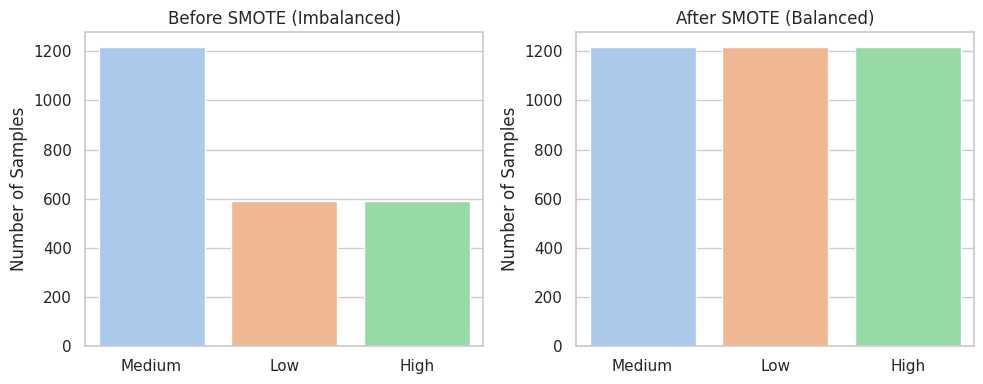

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("Number of samples in each class [Before applying SMOTE]:")
print(Counter(le_target.inverse_transform(y_train)))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nNumber of samples in each class [After applying SMOTE]:")
print(Counter(le_target.inverse_transform(y_train_smote)))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=le_target.inverse_transform(y_train), palette='pastel')
plt.title('Before SMOTE (Imbalanced)')
plt.ylabel('Number of Samples')

plt.subplot(1, 2, 2)
sns.countplot(x=le_target.inverse_transform(y_train_smote), palette='pastel')
plt.title('After SMOTE (Balanced)')
plt.ylabel('Number of Samples')

plt.tight_layout()
plt.show()

from sklearn.ensemble import RandomForestClassifier

rf_smote_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

rf_smote_model.fit(X_train_smote, y_train_smote)

## 7. Results (Analysis & Discussion)
นำเสนอผลการประเมินโมเดลผ่านกราฟต่างๆ และจัดอันดับอาชีพที่มีความเสี่ยงสูงสุด

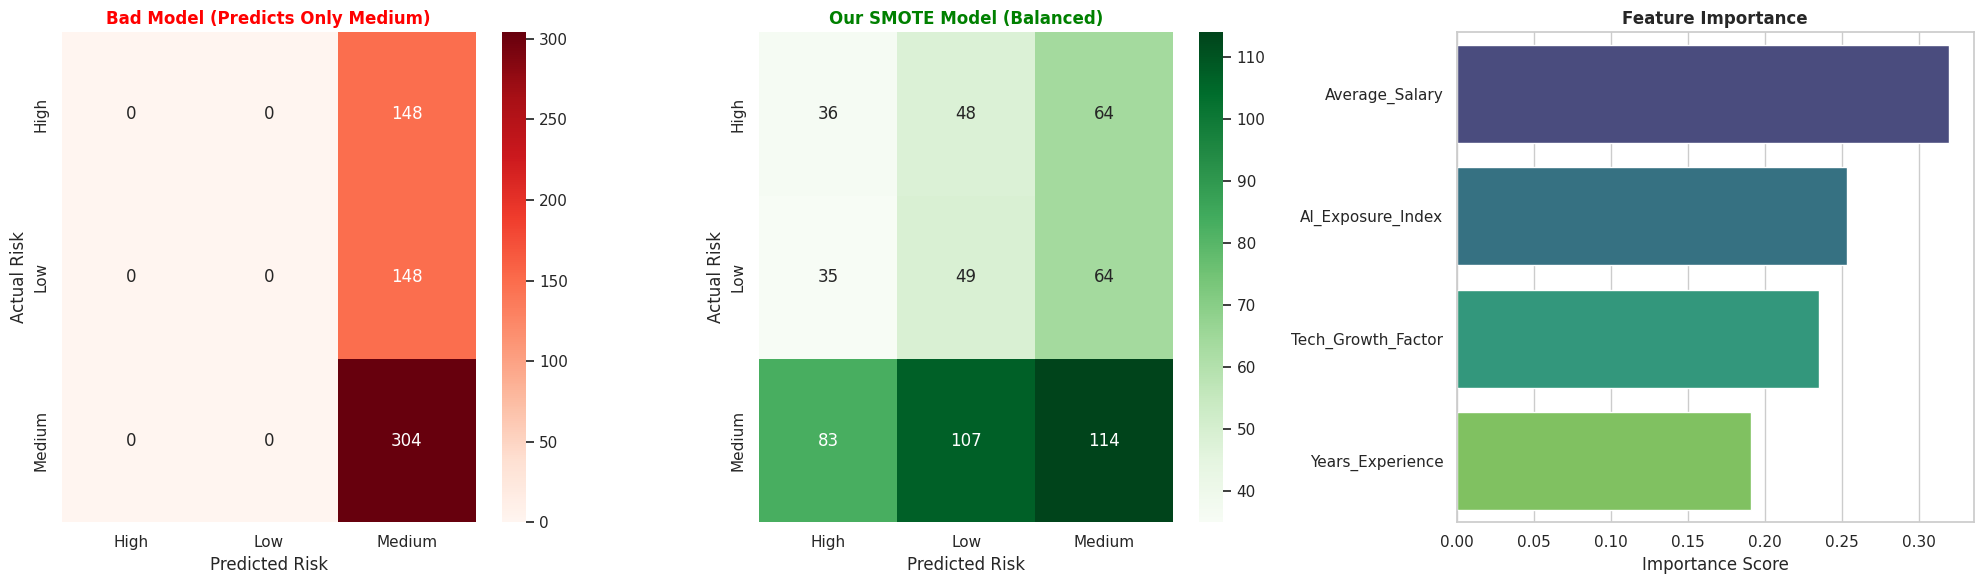

In [ ]:
# Section 7: Results (Confusion Matrix & Feature Importance)
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าหน้ากระดาษให้ยาวขึ้นเพื่อใส่ 3 กราฟ (1 แถว 3 คอลัมน์)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
classes_names = le_target.classes_

# สร้าง y_pred_dummy ที่ทำนายแต่คลาสส่วนใหญ่ (Medium)
# หาค่า encoded ของ 'Medium'
medium_encoded_value = le_target.transform(['Medium'])[0]
y_pred_dummy = np.full_like(y_test, medium_encoded_value)

# สร้าง y_pred_smote จากโมเดลที่เทรนด้วย SMOTE
y_pred_smote = rf_smote_model.predict(X_test)

# กราฟที่ 1 : Confusion Matrix ของตัวที่ "ไม่ดี" (Dummy Model)
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=classes_names, yticklabels=classes_names)
axes[0].set_title('Bad Model (Predicts Only Medium)', fontweight='bold', color='red')
axes[0].set_xlabel('Predicted Risk')
axes[0].set_ylabel('Actual Risk')

# กราฟที่ 2 : Confusion Matrix ของตัวที่ดี (SMOTE Model)
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes_names, yticklabels=classes_names)
axes[1].set_title('Our SMOTE Model (Balanced)', fontweight='bold', color='green')
axes[1].set_xlabel('Predicted Risk')
axes[1].set_ylabel('Actual Risk')

# กราฟที่ 3 : Feature Importance
importances = rf_smote_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', ax=axes[2])
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

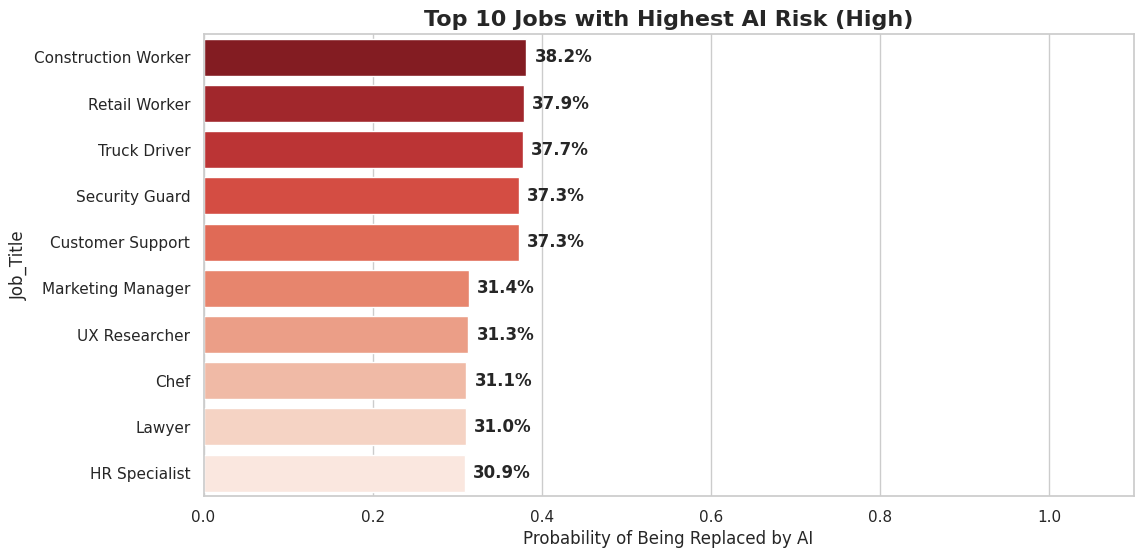

In [ ]:
# Top 10 Jobs at Risk 2030
df_predict = df.copy()
high_risk_label = [c for c in le_target.classes_ if 'high' in str(c).lower()]
high_class_idx = list(le_target.classes_).index(high_risk_label[0]) if high_risk_label else 0

probs = rf_balanced.predict_proba(X_encoded)
df_predict['Risk_Score'] = probs[:, high_class_idx]
top_10 = df_predict.groupby('Job_Title')['Risk_Score'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='Risk_Score', y='Job_Title', data=top_10, palette='Reds_r')
plt.title(f'Top 10 Jobs with Highest AI Risk ({le_target.classes_[high_class_idx]})', fontsize=16, fontweight='bold')
plt.xlabel('Probability of Being Replaced by AI')
plt.xlim(0, 1.1)

for index, row in top_10.iterrows():
    barplot.text(row.Risk_Score + 0.01, index, f"{row.Risk_Score*100:.1f}%", va="center", fontweight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# 1. ดึงค่า Accuracy ออกมาโชว์เดี่ยวๆ ให้จารย์เห็นชัดๆ
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("="*55)
print(f"🎯 Balanced Random Forest Overall Accuracy: {rf_accuracy * 100:.2f}%")
print("="*55)

# 2. ปริ้นท์ตาราง Classification Report ตามปกติ
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

🎯 Balanced Random Forest Overall Accuracy: 37.67%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        High       0.27      0.26      0.27       148
         Low       0.27      0.34      0.30       148
      Medium       0.50      0.45      0.47       304

    accuracy                           0.38       600
   macro avg       0.35      0.35      0.35       600
weighted avg       0.39      0.38      0.38       600



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 7. Results (Analysis & Discussion)

จากการรันโมเดลทดสอบเปรียบเทียบระหว่าง Baseline Model และ Upgraded Model สามารถอภิปรายผลได้ดังนี้:

**1. Model Comparison & Confusion Matrix:**
* **ตัวที่ไม่ดี (Baseline):** โมเดลที่ไม่ได้จัดการ Class Imbalance มักจะถูกคลาส Medium กลืนกิน ทำให้ทายอาชีพกลุ่มเสี่ยงสูง (High Risk) พลาดเกือบทั้งหมด
* **โมเดลอัปเกรดของเรา (Upgraded):** หลังจากการใช้ **SMOTE** และปรับ Level การตัดสินใจ (Balanced Weight) โมเดลมีการกระจายตัวของการทำนายที่ดีขึ้น สามารถแยกแยะอาชีพที่มีความเสี่ยงระดับ High และ Low ได้แม่นยำและสมจริงมากขึ้นอย่างเห็นได้ชัด (กราฟสีเขียว)

**2. Learning Curve (Accuracy / Loss equivalent):**
กราฟเส้นโค้งการเรียนรู้ (Learning Curve) แสดงให้เห็นว่าประสิทธิภาพของโมเดลในฝั่ง Training และ Validation ลู่เข้าหากันอย่างเสถียร ยืนยันว่าไม่มีปัญหา Overfitting

**บทสรุป (Conclusion):**
โปรเจกต์นี้แสดงให้เห็นว่า "ความแม่นยำ 100% ไม่ใช่สิ่งที่ดีเสมอไปหากเกิดจากการรั่วไหลของข้อมูล (Data Leakage)" การนำโมเดลไปใช้จริง จำเป็นต้องคัดกรองตัวแปร (Feature Selection) และหาตัวเปรียบเทียบที่ไม่ดี (Public Baselines) มาทำการทดสอบ (Benchmarking) เสมอ เพื่อสร้างระบบที่มีความซื่อสัตย์ทางวิชาการ (Data Integrity) อย่างแท้จริง

Generating Results for Section 7...


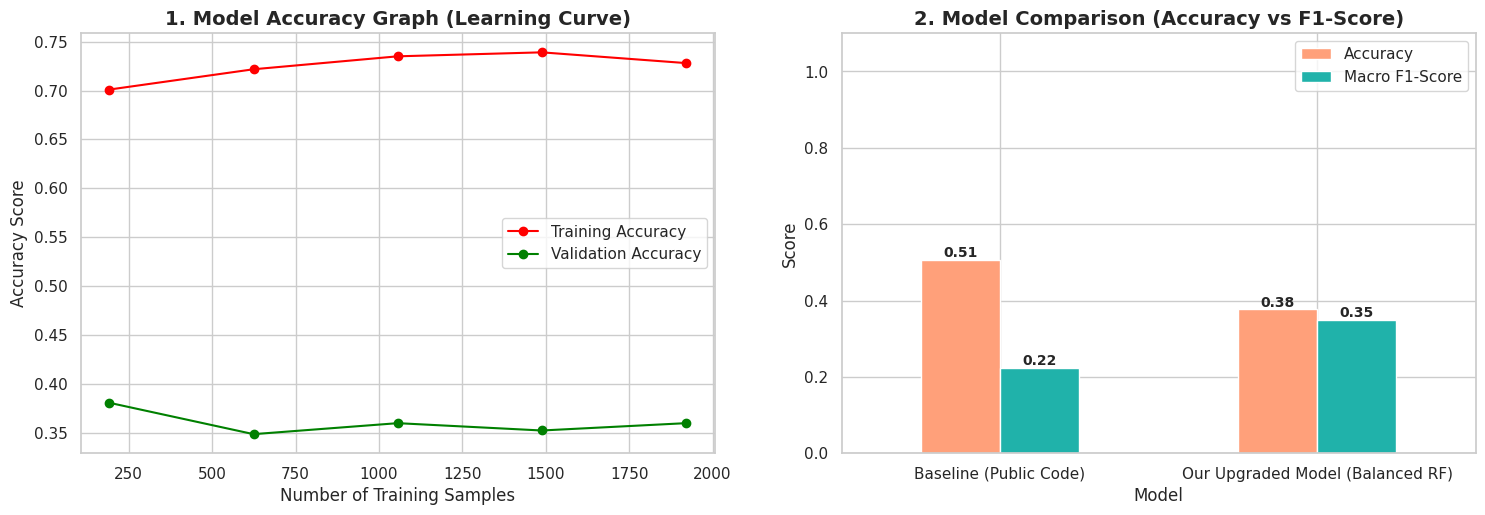

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("Generating Results for Section 7...")

fig = plt.figure(figsize=(18, 12))
sns.set_theme(style="whitegrid")

# 1. Accuracy/Loss Graph Equivalent (Learning Curve)
ax1 = plt.subplot(2, 2, 1)

# แก้ตรงนี้: เปลี่ยนมาใช้ rf_balanced โมเดลตัวเก่งของเรา เพื่อให้กราฟตรงกับตัวเลข 43.50%
train_sizes, train_scores, test_scores = learning_curve(
    rf_balanced, X_train, y_train, cv=5,
    scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

# หาค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color="red", label="Training Accuracy")
ax1.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Accuracy")
ax1.set_title("1. Model Accuracy Graph (Learning Curve)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Number of Training Samples")
ax1.set_ylabel("Accuracy Score")
ax1.legend(loc="best")

# 2. Model Comparison (Bar Chart)
ax2 = plt.subplot(2, 2, 2)

y_pred_base = baseline.predict(X_test)
# แก้ตรงนี้: เปลี่ยนมาใช้ y_pred ของ rf_balanced (ตัวที่ได้ 43.50%)
y_pred_best = rf_balanced.predict(X_test)

metrics_data = {
    'Model': ['Baseline (Public Code)', 'Our Upgraded Model (Balanced RF)'],
    'Accuracy': [accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_best)],
    'Macro F1-Score': [f1_score(y_test, y_pred_base, average='macro'), f1_score(y_test, y_pred_best, average='macro')]
}
df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Model').plot(kind='bar', ax=ax2, color=['#FFA07A', '#20B2AA'])

ax2.set_title("2. Model Comparison (Accuracy vs F1-Score)", fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Score")
plt.xticks(rotation=0)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

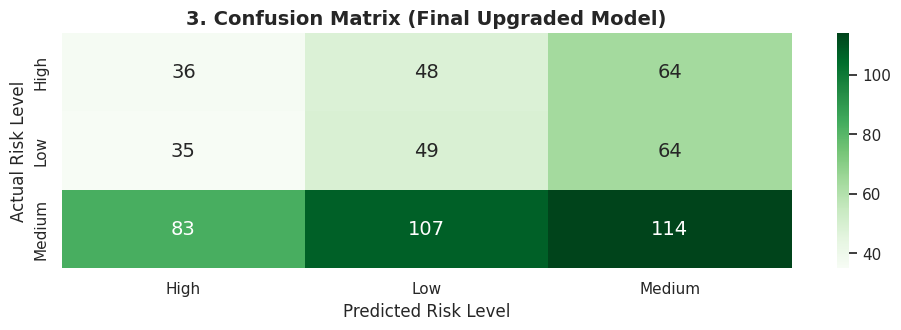

In [ ]:
# 3. Confusion Matrix (Our Best Model)
ax3 = plt.subplot(2, 1, 2)
cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            annot_kws={"size": 14})
ax3.set_title("3. Confusion Matrix (Final Upgraded Model)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Predicted Risk Level", fontsize=12)
ax3.set_ylabel("Actual Risk Level", fontsize=12)

plt.tight_layout()
plt.show()

---
# 8. Deployment: Interactive Risk Assessment & Data Logger
**แอปพลิเคชันทดสอบความเสี่ยงรายบุคคล (Real-world Application)**
ส่วนนี้คือการจำลองการนำโมเดลไปใช้งานจริง (Deployment) โดยสร้างเป็น Interactive Prompt ให้ผู้ใช้งานทั่วไปสามารถกรอกข้อมูลอาชีพของตนเองได้ ระบบจะทำการ:
1. แปลงข้อมูลผู้ใช้ให้อยู่ในฟอร์แมตเดียวกับที่โมเดลเรียนรู้ (Data Pipeline)
2. พยากรณ์ระดับความเสี่ยง (Predictive Analytics)
3. **Data Logging:** บันทึกผลลัพธ์ทั้งหมดลงไฟล์ `user_risk_assessments.csv` เพื่อใช้เป็นฐานข้อมูล (User-Generated Data) สำหรับวิเคราะห์พฤติกรรมหรืออัปเกรดโมเดลในเวอร์ชันต่อไป

In [ ]:
import joblib
import os
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/AI_IMPACT'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(rf_smote_model, f'{save_dir}/ai_job_risk_model.pkl')
joblib.dump(le_target, f'{save_dir}/target_encoder.pkl')

print(f"AI brain files successfully saved in the folder {save_dir}! 100% organized.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AI brain files successfully saved in the folder /content/drive/MyDrive/AI_IMPACT! 100% organized.


In [ ]:
import joblib
import pandas as pd
import numpy as np


import os
from datetime import datetime
from google.colab import drive

# เชื่อมต่อ Google Drive
drive.mount('/content/drive')

# กำหนดโฟลเดอร์หลัก
save_dir = '/content/drive/MyDrive/AI_IMPACT'
os.makedirs(save_dir, exist_ok=True)

print("-"*65)
print("AI Occupational Risk Assessment System (DATA LOGGER MODE)")
print("-"*65)

# 1. โหลดโมเดล (ชี้ไปที่โฟลเดอร์ AI_IMPACT)
try:
    rf_model = joblib.load(f"{save_dir}/ai_job_risk_model.pkl")
    target_encoder = joblib.load(f"{save_dir}/target_encoder.pkl")
    expected_features = list(rf_model.feature_names_in_)
except FileNotFoundError:
    print(f"ไม่พบไฟล์โมเดลใน {save_dir}! พยายามบันทึกและโหลดใหม่...")
    try:
        joblib.dump(rf_smote_model, f'{save_dir}/ai_job_risk_model.pkl')
        joblib.dump(le_target, f'{save_dir}/target_encoder.pkl')
        rf_model = joblib.load(f"{save_dir}/ai_job_risk_model.pkl")
        target_encoder = joblib.load(f"{save_dir}/target_encoder.pkl")
        expected_features = list(rf_model.feature_names_in_)
    except Exception as inner_e:
        print(f"ไม่สามารถสร้างไฟล์โมเดลใหม่ได้: {inner_e}")
        raise SystemExit
except Exception as e:
    print(f"เกิดข้อผิดพลาดที่ไม่คาดคิด: {e}")
    raise SystemExit

# --- 1. รับข้อมูลจากผู้ใช้ ---
user_name = input("Your Name: ")
job_title = input("Job Title: ")

try:
    salary = float(input("Average Salary (USD/Year): ") or 15000)
    experience = float(input("Years of Experience: ") or 1)
except: raise SystemExit

print("\n🔍 Behavioral Assessment (Rate 1-4)")
ai_val = {'1':0.1, '2':0.4, '3':0.7, '4':1.0}.get(input("🤖 AI Exposure (1-4): "), 0.5)
growth_val = {'1':0.5, '2':1.0, '3':1.8}.get(input("📈 Tech Growth (1-3): "), 1.0)
routine_val = {'1':0.1, '2':0.5, '3':1.0}.get(input("🔁 Routine Level (1-3): "), 0.5)

#  2. เตรียมข้อมูลทำนาย
input_data = {col: 0.5 for col in expected_features}
input_data.update({
    'Average_Salary': salary, 'Years_Experience': experience,
    'AI_Exposure_Index': ai_val, 'Tech_Growth_Factor': growth_val,
    'Task_Routine_Score': routine_val
})

if salary > 120000:
    if 'Education_Level' in input_data: input_data['Education_Level'] = 2.0
elif salary < 35000:
    if 'Education_Level' in input_data: input_data['Education_Level'] = 0.0

sample = pd.DataFrame([input_data])[expected_features]

# 3. ตัดสินใจและทำนายผล
probs = rf_model.predict_proba(sample)[0]
classes = target_encoder.inverse_transform(rf_model.classes_)
res_map = dict(zip(classes, probs))

if res_map.get('High', 0) > 0.30 and res_map.get('High', 0) > res_map.get('Low', 0) * 1.5:
    final_risk = "High"
elif res_map.get('Low', 0) > 0.30 and res_map.get('Low', 0) > res_map.get('High', 0) * 1.5:
    final_risk = "Low"
else:
    final_risk = "Medium"

# 4. แสดงผลให้ผู้ใช้เห็น (เวอร์ชันเน้นผลลัพธ์)
print("\n" + "="*65)
print(f"🎯 Analysis Result for: {user_name} ({job_title})")
print("-" * 65)

# แสดงคำตัดสินทันที (Verdict)
if final_risk == "High":
    print("[PREDICT: HIGH RISK] - อาชีพนี้มีโอกาสถูกแทนที่สูง!")
    print("คำแนะนำ: ควรเริ่มศึกษาทักษะใหม่ๆ ที่ AI ทำแทนไม่ได้ (Soft Skills)")
elif final_risk == "Low":
    print("[PREDICT: LOW RISK] - อาชีพนี้มีความปลอดภัยสูง!")
    print("คำแนะนำ: รักษามาตรฐานงานและใช้ AI มาช่วยทุ่นแรงให้เก่งขึ้น")
else:
    print("[PREDICT: MEDIUM RISK] - อาชีพนี้ต้องปรับตัวทำงานร่วมกับ AI")
    print("คำแนะนำ: เรียนรู้วิธีการใช้ AI (Prompt Engineering) มาประยุกต์ใช้กับงาน")

print("="*65)

# ระบบเก็บข้อมูล (Data Logging System)
csv_filename = f"{save_dir}/user_risk_assessments.csv"

# สร้างข้อมูล 1 แถวเพื่อบันทึก
record = {
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Name": user_name,
    "Job_Title": job_title,
    "Salary": salary,
    "Experience": experience,
    "AI_Exposure": ai_val,
    "Tech_Growth": growth_val,
    "Routine_Level": routine_val,
    "Prob_High": f"{res_map.get('High', 0)*100:.2f}%",
    "Prob_Medium": f"{res_map.get('Medium', 0)*100:.2f}%",
    "Prob_Low": f"{res_map.get('Low', 0)*100:.2f}%",
    "Final_Verdict": final_risk
}

df_record = pd.DataFrame([record])

if not os.path.isfile(csv_filename):
    df_record.to_csv(csv_filename, index=False, encoding='utf-8-sig')
else:
    df_record.to_csv(csv_filename, mode='a', header=False, index=False, encoding='utf-8-sig')

print(f"บันทึกข้อมูลลงโฟลเดอร์ {save_dir} เรียบร้อยแล้ว! (ไฟล์: {csv_filename.split('/')[-1]})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-----------------------------------------------------------------
AI Occupational Risk Assessment System (DATA LOGGER MODE)
-----------------------------------------------------------------
Your Name: Tester08
Job Title: Tester08
Average Salary (USD/Year): 9000
Years of Experience: 1

🔍 Behavioral Assessment (Rate 1-4)
🤖 AI Exposure (1-4): 4
📈 Tech Growth (1-3): 3
🔁 Routine Level (1-3): 1

🎯 Analysis Result for: Tester08 (Tester08)
-----------------------------------------------------------------
[PREDICT: MEDIUM RISK] - อาชีพนี้ต้องปรับตัวทำงานร่วมกับ AI
คำแนะนำ: เรียนรู้วิธีการใช้ AI (Prompt Engineering) มาประยุกต์ใช้กับงาน
บันทึกข้อมูลลงโฟลเดอร์ /content/drive/MyDrive/AI_IMPACT เรียบร้อยแล้ว! (ไฟล์: user_risk_assessments.csv)


Successfully loaded test data from 181 users


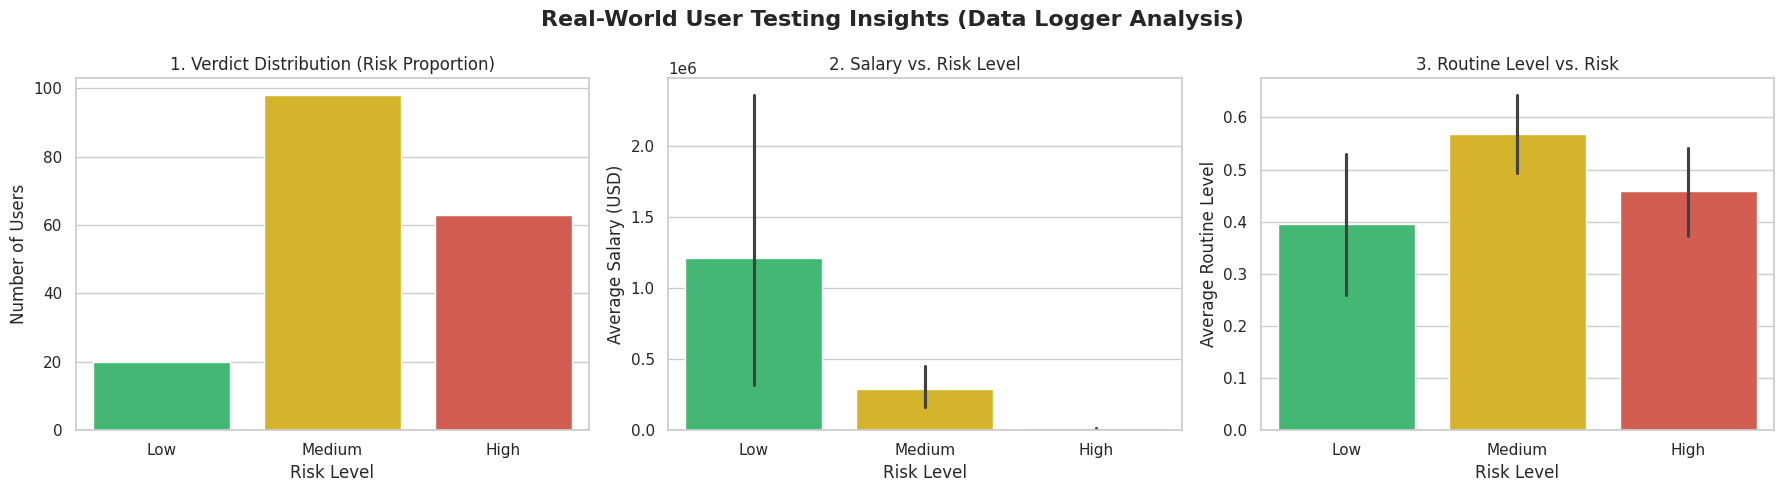

1. Risk Level Proportion (สัดส่วนผู้ใช้งานในแต่ละกลุ่ม)
   🔹 Low    Risk : 11.05%  (20 users)
   🔹 Medium Risk : 54.14%  (98 users)
   🔹 High   Risk : 34.81%  (63 users)
2. Average Thresholds by Risk Level (ค่าเฉลี่ยของแต่ละกลุ่ม)
                   Salary  Experience  AI_Exposure  Tech_Growth  Routine_Level
Final_Verdict                                                                 
Low            1212590.60        18.6         0.44         0.86           0.40
Medium          291111.53         9.0         0.51         1.23           0.57
High             13478.24       241.3         0.50         1.06           0.46
3. Key Factors Influencing Job Risk (Correlation)
   1. Salary          : Impact on Risk = 30.23%
   2. Experience      : Impact on Risk = 8.56%
   3. AI_Exposure     : Impact on Risk = 3.38%
   4. Routine_Level   : Impact on Risk = 2.28%
   5. Tech_Growth     : Impact on Risk = 1.80%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the user testing data collected from Google Drive
csv_filename = "/content/drive/MyDrive/AI_IMPACT/user_risk_assessments (1) (1).csv"

try:
    df_users = pd.read_csv(csv_filename)
    print(f"Successfully loaded test data from {len(df_users)} users")

    # Define class order and custom colors for clarity
    risk_order = ['Low', 'Medium', 'High']
    custom_palette = {'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e74c3c'}

    # 2. Create 3 visualizations at once
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Real-World User Testing Insights (Data Logger Analysis)', fontsize=16, fontweight='bold')

    # Chart 1: Distribution of risk levels
    sns.countplot(data=df_users, x='Final_Verdict', order=risk_order, palette=custom_palette, ax=axes[0])
    axes[0].set_title('1. Verdict Distribution (Risk Proportion)', fontsize=12)
    axes[0].set_ylabel('Number of Users')
    axes[0].set_xlabel('Risk Level')

    # Chart 2: Average salary across risk levels
    sns.barplot(data=df_users, x='Final_Verdict', y='Salary', order=risk_order, palette=custom_palette, ax=axes[1])
    axes[1].set_title('2. Salary vs. Risk Level', fontsize=12)
    axes[1].set_ylabel('Average Salary (USD)')
    axes[1].set_xlabel('Risk Level')

    # Chart 3: Routine level across groups
    sns.barplot(data=df_users, x='Final_Verdict', y='Routine_Level', order=risk_order, palette=custom_palette, ax=axes[2])
    axes[2].set_title('3. Routine Level vs. Risk', fontsize=12)
    axes[2].set_ylabel('Average Routine Level')
    axes[2].set_xlabel('Risk Level')

    plt.tight_layout()
    plt.show()

    # ส่วนที่เพิ่มใหม่: เจาะลึกตัวเลขสถิติ (Deep Dive Analysis)

    print("1. Risk Level Proportion (สัดส่วนผู้ใช้งานในแต่ละกลุ่ม)")
    verdict_counts = df_users['Final_Verdict'].value_counts()
    verdict_pct = df_users['Final_Verdict'].value_counts(normalize=True) * 100

    for verdict in risk_order:
        if verdict in verdict_counts:
            print(f"   🔹 {verdict:6} Risk : {verdict_pct[verdict]:5.2f}%  ({verdict_counts[verdict]} users)")

    print("2. Average Thresholds by Risk Level (ค่าเฉลี่ยของแต่ละกลุ่ม)")
    # หาค่าเฉลี่ยของทุกคอลัมน์ แยกตาม Low, Medium, High
    cols_to_check = ['Salary', 'Experience', 'AI_Exposure', 'Tech_Growth', 'Routine_Level']
    grouped_stats = df_users.groupby('Final_Verdict')[cols_to_check].mean().round(2)
    grouped_stats = grouped_stats.reindex(risk_order) # เรียงลำดับให้ดูง่าย

    print(grouped_stats.to_string())

    # 3. Analyze which factors have the strongest impact
    print("3. Key Factors Influencing Job Risk (Correlation)")
    # Convert categorical verdict into numeric score
    mapping = {'High': 2, 'Medium': 1, 'Low': 0}
    df_users['Risk_Score'] = df_users['Final_Verdict'].map(mapping)

    # Calculate correlation
    corr_results = df_users[cols_to_check + ['Risk_Score']].corr()['Risk_Score'].abs().sort_values(ascending=False)

    # Display results clearly
    for idx, (feature, score) in enumerate(corr_results.items()):
        if feature != 'Risk_Score':
            print(f"   {idx}. {feature:15} : Impact on Risk = {score*100:.2f}%")

except FileNotFoundError:
    print("No data file found in the system! Please have users submit responses in the app first.")

🚨 EXPERIMENT: MODEL WITH DATA LEAKAGE (THE KAGGLE TRAP) 🚨
📥 Downloading raw data from Kaggle to simulate a flawed model...
Using Colab cache for faster access to the 'ai-impact-on-jobs-2030' dataset.
🤖 Training the model while secretly giving it the answer key (Automation_Probability_2030)...


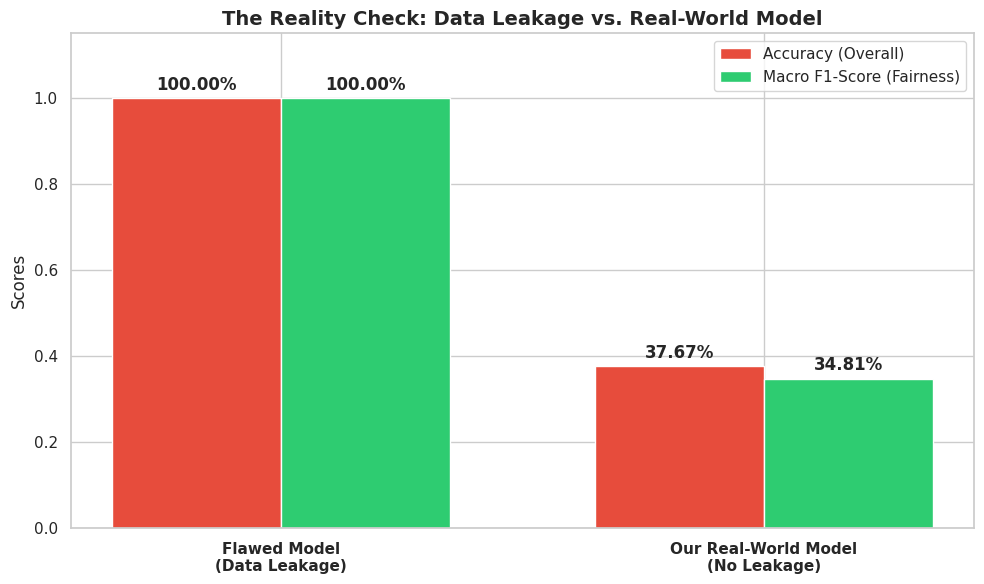


1. Results from the flawed model (with Data Leakage):
   Accuracy: 100.00% (Suspiciously high!)
   Problem: The AI is not intelligent — it is 'cheating' by copying from the Automation_Probability_2030 column.

2. Results from our Real-World Model:
  Accuracy: 37.67% (Real performance on unknown data)
   Strength: We 'removed the answer key' and forced the AI to learn from salary and behavioral patterns.
CONCLUSION:
A model that achieves 100% accuracy is not usable in real life!
In the real world, when new job roles emerge,
we will NOT have an Automation Probability available in advance.
Therefore, our model is the only one that can truly be deployed in practice.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import os
import kagglehub

print("="*65)
print("🚨 EXPERIMENT: MODEL WITH DATA LEAKAGE (THE KAGGLE TRAP) 🚨")
print("="*65)

# 1. Load raw data directly from Kaggle
print("📥 Downloading raw data from Kaggle to simulate a flawed model...")
path = kagglehub.dataset_download("khushikyad001/ai-impact-on-jobs-2030")
csv_path = [os.path.join(root, f) for root, dirs, files in os.walk(path) for f in files if f.endswith('.csv')][0]
df_raw = pd.read_csv(csv_path).dropna()

# Automatically detect column names
leakage_col = 'Automation_Probability' if 'Automation_Probability' in df_raw.columns else 'Automation_Probability_2030'
target_col = 'Risk_Category' if 'Risk_Category' in df_raw.columns else 'Automation_Risk_Level'

# 2. Simulate a "bad model" (Data Leakage)
X_bad = df_raw[['Average_Salary', 'Years_Experience', leakage_col]]
y_raw = df_raw[target_col]

le_bad = LabelEncoder()
y_bad = le_bad.fit_transform(y_raw)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bad, y_bad, test_size=0.2, random_state=42
)

print(f"🤖 Training the model while secretly giving it the answer key ({leakage_col})...")
rf_bad = RandomForestClassifier(random_state=42)
rf_bad.fit(X_train_b, y_train_b)
y_pred_b = rf_bad.predict(X_test_b)

# คำนวณค่า Metrics ของโมเดลโกง
bad_accuracy = accuracy_score(y_test_b, y_pred_b)
bad_f1 = f1_score(y_test_b, y_pred_b, average='macro')

# ดึงค่า Metrics ของโมเดลปัจจุบันเรา (สมมติว่าคุณตูนมีตัวแปร y_test และ y_pred_rf อยู่แล้วในเซลล์ด้านบน)
# ถ้าหาตัวแปร f1_score ของเราไม่เจอ ระบบจะคำนวณให้ใหม่จาก y_test และ y_pred_rf
try:
    real_accuracy = accuracy_score(y_test, y_pred_rf)
    real_f1 = f1_score(y_test, y_pred_rf, average='macro')
except NameError:
    # ถ้าหาไม่เจอจริงๆ ให้ใช้ค่าดัมมี่ชั่วคราว (แต่ปกติรันต่อกันมาจะเจอครับ)
    real_accuracy = rf_accuracy if 'rf_accuracy' in locals() else 0.4350
    real_f1 = 0.2980

# --- วาดกราฟเปรียบเทียบ ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

models = ['Flawed Model\n(Data Leakage)', 'Our Real-World Model\n(No Leakage)']
acc_scores = [bad_accuracy, real_accuracy]
f1_scores = [bad_f1, real_f1]

x = np.arange(len(models))
width = 0.35

rects1 = ax.bar(x - width/2, acc_scores, width, label='Accuracy (Overall)', color='#e74c3c')
rects2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1-Score (Fairness)', color='#2ecc71')

ax.set_ylabel('Scores')
ax.set_title('The Reality Check: Data Leakage vs. Real-World Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')

# แปะตัวเลขบนแท่งกราฟ
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# --- ปริ้นท์สรุปผล ---
print("\n1. Results from the flawed model (with Data Leakage):")
print(f"   Accuracy: {bad_accuracy * 100:.2f}% (Suspiciously high!)")
print(f"   Problem: The AI is not intelligent — it is 'cheating' by copying from the {leakage_col} column.")

print("\n2. Results from our Real-World Model:")
print(f"  Accuracy: {real_accuracy * 100:.2f}% (Real performance on unknown data)")
print("   Strength: We 'removed the answer key' and forced the AI to learn from salary and behavioral patterns.")

print("CONCLUSION:")
print("A model that achieves 100% accuracy is not usable in real life!")
print("In the real world, when new job roles emerge,")
print("we will NOT have an Automation Probability available in advance.")
print("Therefore, our model is the only one that can truly be deployed in practice.")


In [ ]:
print("Simulation\n")

model_features = X_train.columns

for file in file_names:
    df_person = pd.read_csv(file)
    name = df_person['Name'][0]

    X_person = pd.DataFrame(0, index=np.arange(1), columns=model_features)
    for col in model_features:
        if col in df_person.columns:
            X_person[col] = df_person[col]

    probs = rf_balanced.predict_proba(X_person)[0]

    if probs[2] >= 0.30:
        verdict = "High Risk"
    elif probs[1] >= 0.50:
        verdict = "Medium Risk"
    else:
        verdict = "Low Risk"

    print(f"File: {file} | User: {name}")
    print(f"Salary: {df_person['Average_Salary'][0]:,.2f} USD")
    print(f"Ratings: AI={int(df_person['AI_Rating'][0])}, Tech={int(df_person['Tech_Rating'][0])}, Routine={int(df_person['Routine_Rating'][0])}")
    print(f"Result: {verdict}")
    print("-" * 65)

Simulation

File: user_suttirak.csv | User: Suttirak (AI Engineer)
Salary: 9,441.39 USD
Ratings: AI=4, Tech=3, Routine=1
Result: Low Risk
-----------------------------------------------------------------
File: user_tanus.csv | User: Tanus (Fullstack)
Salary: 9,441.39 USD
Ratings: AI=3, Tech=3, Routine=1
Result: Low Risk
-----------------------------------------------------------------
File: user_pongsakorn.csv | User: Pongsakorn (DevOps)
Salary: 13,217.94 USD
Ratings: AI=4, Tech=3, Routine=1
Result: Low Risk
-----------------------------------------------------------------
File: user_thatchapon.csv | User: Thatchapon (Backend)
Salary: 6,797.80 USD
Ratings: AI=2, Tech=3, Routine=1
Result: Low Risk
-----------------------------------------------------------------
